# CIFAR-10 Enhanced Pixel-Space DP-VAE

This is the thesis-facing notebook for the CIFAR-10 pixel-space generator.

- The model is a **VAE trained directly on RGB pixels**, which is why we call it **pixel-space**.
- Earlier code called this variant `DP-VAE++`; in the thesis we use **enhanced pixel-space DP-VAE** because it is still a VAE, not a diffusion model.
- The "enhanced" part refers to the **De-et-al.-inspired DP training recipe**: GroupNorm, augmentation multiplicity, large logical batches with microbatching, KL warm-up, and EMA.

This notebook does one thing only: reproduce the **synthetic-only downstream utility** across privacy budgets and save the exact CSV files used by the thesis figure export.

## 1. Setup

In [ ]:
from pathlib import Path
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from opacus.accountants.utils import get_noise_multiplier

cwd = Path.cwd().resolve()
if (cwd / 'strategy').exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = next(p for p in [cwd, *cwd.parents] if (p / 'strategy').exists())

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_loader import load_cifar10_federated_data
from models.cifar.cifar_cnn import CIFAR_CNN
from models.cifar.train_cifar_vae import train_cifar_vae_dp
from visual.thesis_style import apply_thesis_style, EPSILON_COLORS, EPS_LABELS, EPS_ORDER, save_thesis_fig

apply_thesis_style()

def get_best_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


DEVICE = get_best_device()
print('Repo root:', REPO_ROOT)
print('Device:', DEVICE)

## 2. Configuration

In [2]:
SEED = 42

# Data
TOTAL_N = 8000
BATCH_SIZE = 64

# Enhanced pixel-space DP-VAE config (ablation-best setup)
SYN_EPOCHS = 40
SYN_LOGICAL_BATCH = 512
SYN_LATENT_DIM = 96
SYN_LR = 1e-3
MAX_GRAD_NORM = 1.0
DELTA = 1e-5
IMG_SIZE = 32
SYNTHETIC_COUNT = 500

# Evaluation
EPSILON_GRID = [None, 8.0, 1.0]
MULTI_SEEDS = [42]
CLS_EPOCHS = 10
CLS_LR = 1e-3

print({
    'seed': SEED,
    'total_n': TOTAL_N,
    'syn_epochs': SYN_EPOCHS,
    'syn_logical_batch': SYN_LOGICAL_BATCH,
    'syn_latent_dim': SYN_LATENT_DIM,
    'synthetic_count': SYNTHETIC_COUNT,
    'epsilon_grid': EPSILON_GRID,
    'multi_seeds': MULTI_SEEDS,
})

{'seed': 42, 'total_n': 8000, 'syn_epochs': 40, 'syn_logical_batch': 512, 'syn_latent_dim': 96, 'synthetic_count': 500, 'epsilon_grid': [None, 8.0, 1.0], 'multi_seeds': [42]}


## 3. Load CIFAR-10

In [3]:
trainloader, testloader = load_cifar10_federated_data(
    partition_id=-1,
    num_clients=1,
    non_iid_alpha=float('inf'),
    batch_size=BATCH_SIZE,
    total_n=TOTAL_N,
    partitioning='iid',
    cache_dir=str(REPO_ROOT / 'data' / 'cifar10'),
    seed=SEED,
    log_distribution=False,
)

train_images, train_labels = [], []
for x, y in trainloader:
    train_images.append(x)
    train_labels.append(y)

train_x = torch.cat(train_images, dim=0)
train_y = torch.cat(train_labels, dim=0)

print('Train tensor:', tuple(train_x.shape), tuple(train_y.shape))
print('Test dataset size:', len(testloader.dataset))
print('Class counts:', {int(c): int((train_y == c).sum()) for c in torch.unique(train_y)})

Train tensor: (8000, 3, 32, 32) (8000,)
Test dataset size: 10000
Class counts: {0: 810, 1: 772, 2: 777, 3: 750, 4: 814, 5: 797, 6: 828, 7: 818, 8: 800, 9: 834}


## 4. Helpers

In [4]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_and_eval_classifier(syn_x: torch.Tensor, syn_y: torch.Tensor, epochs: int, lr: float, seed: int) -> float:
    """Train a CIFAR classifier on synthetic data and evaluate on the real test set."""
    seed_everything(seed)
    model = CIFAR_CNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(syn_x, syn_y), batch_size=BATCH_SIZE, shuffle=True)

    model.train()
    for _ in range(epochs):
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return correct / max(total, 1)

## 5. Multi-Seed Synthetic-Only Utility

This is the only experiment the thesis figure depends on. For each privacy budget, we train the enhanced pixel-space DP-VAE, sample synthetic data, train a CIFAR classifier on synthetic-only data, and evaluate it on the real test set.

In [5]:
multi_records = []

for eps in EPSILON_GRID:
    eps_label = 'No DP' if eps is None else f'eps={eps:g}'
    noise = 0.0
    if eps is not None:
        sample_rate = min(SYN_LOGICAL_BATCH / max(500, 1), 0.99)
        noise = float(get_noise_multiplier(
            target_epsilon=float(eps),
            target_delta=DELTA,
            sample_rate=sample_rate,
            epochs=SYN_EPOCHS,
        ))
    print(f'\n--- {eps_label} (noise={noise:.4f}) ---')

    for seed in MULTI_SEEDS:
        seed_everything(seed)
        syn_x, syn_y, _, eps_by_label = train_cifar_vae_dp(
            data_tensor=train_x,
            label_tensor=train_y,
            epochs=SYN_EPOCHS,
            batch_size=SYN_LOGICAL_BATCH,
            latent_dim=SYN_LATENT_DIM,
            noise_multiplier=noise,
            max_grad_norm=MAX_GRAD_NORM,
            kl_warmup=10,
            lr=SYN_LR,
            delta=DELTA,
            img_size=IMG_SIZE,
            scale_syn=False,
            synthetic_count=SYNTHETIC_COUNT,
            seed=seed,
            eval_metrics=False,
            device=DEVICE,
        )
        mean_epsilon = float(np.mean(list(eps_by_label.values()))) if eps_by_label else float('inf')
        acc = train_and_eval_classifier(syn_x, syn_y, epochs=CLS_EPOCHS, lr=CLS_LR, seed=seed)
        multi_records.append({
            'eps_label': eps_label,
            'target_epsilon': float('inf') if eps is None else float(eps),
            'mean_epsilon': mean_epsilon,
            'seed': seed,
            'acc': acc,
        })
        print(f'  seed={seed}: acc={acc:.4f}')


--- No DP (noise=0.0000) ---
[CIFAR10-DP-FedAug] Found labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[CIFAR10-DP-FedAug] Label 0: 810 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 0 complete. ε=∞
[CIFAR10-DP-FedAug] Label 1: 772 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 1 complete. ε=∞
[CIFAR10-DP-FedAug] Label 2: 777 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 2 complete. ε=∞
[CIFAR10-DP-FedAug] Label 3: 750 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 3 complete. ε=∞
[CIFAR10-DP-FedAug] Label 4: 814 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 4 complete. ε=∞
[CIFAR10-DP-FedAug] Label 5: 797 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 5 complete. ε=∞
[CIFAR10-DP-FedAug] Label 6: 828 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 6 complete. ε=∞
[CIFAR10-DP-FedAug] Label 7: 818 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 7 complete. ε=∞
[CIFAR10-DP-FedAug] Label 8: 800 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 8 complete. ε=∞
[CIFAR10-DP-FedAug] Label 9: 834

<repo>/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[CIFAR10-DP-FedAug] Label 0 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 1: 772 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 1 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 2: 777 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 2 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 3: 750 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 3 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 4: 814 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 4 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 5: 797 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 5 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 6: 828 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 6 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 7: 818 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 7 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 8: 800 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 8 complete. ε=5.18
[CIFAR10-DP-FedAug] Label 9: 834 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 9 complete. ε=5.18
  seed=42: acc=0.2412

--- eps=1 (noise=25.4688) ---
[C

<repo>/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


[CIFAR10-DP-FedAug] Label 0 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 1: 772 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 1 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 2: 777 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 2 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 3: 750 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 3 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 4: 814 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 4 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 5: 797 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 5 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 6: 828 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 6 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 7: 818 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 7 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 8: 800 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 8 complete. ε=0.64
[CIFAR10-DP-FedAug] Label 9: 834 real -> 500 synthetic
[CIFAR10-DP-FedAug] Label 9 complete. ε=0.64
  seed=42: acc=0.2156


## 6. Aggregate and Save

In [6]:
multi_df = pd.DataFrame(multi_records)
multi_agg = multi_df.groupby('eps_label', sort=False).agg(
    acc_mean=('acc', 'mean'),
    acc_std=('acc', 'std'),
    n_runs=('seed', 'count'),
).reset_index()

sort_order = {'No DP': 0, 'eps=8': 1, 'eps=4': 2, 'eps=2': 3, 'eps=1': 4}
multi_agg['sort_order'] = multi_agg['eps_label'].map(sort_order)
multi_agg = multi_agg.sort_values('sort_order').reset_index(drop=True)

display_df = multi_agg.copy()
display_df['accuracy'] = display_df.apply(
    lambda r: f"{r['acc_mean']*100:.2f} ± {r['acc_std']*100:.2f}%", axis=1
)
display(display_df[['eps_label', 'accuracy', 'n_runs']])

results_dir = REPO_ROOT / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
raw_csv = results_dir / 'cifar_dpvae_pp_utility_raw.csv'
agg_csv = results_dir / 'cifar_dpvae_pp_utility_agg.csv'
multi_df.to_csv(raw_csv, index=False)
multi_agg.to_csv(agg_csv, index=False)

print('Saved raw:', raw_csv)
print('Saved agg:', agg_csv)

,eps_label,accuracy,n_runs
0,No DP,27.25 ± nan%,1
1,eps=8,24.12 ± nan%,1
2,eps=1,21.56 ± nan%,1


Saved raw: <repo>/results/cifar_dpvae_pp_utility_raw.csv
Saved agg: <repo>/results/cifar_dpvae_pp_utility_agg.csv


## 7. Plot

Saved to: <repo>/results/cifar_dpvae_pp_utility.png


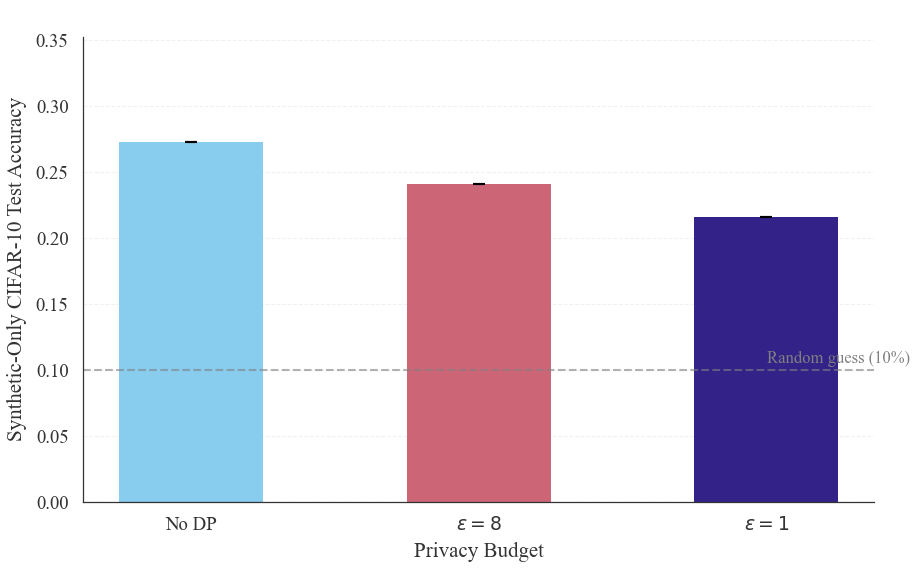

In [17]:
from visual.thesis_style import apply_thesis_style, EPSILON_COLORS, EPS_LABELS
apply_thesis_style()
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

means = multi_agg['acc_mean'].tolist()
stds = multi_agg['acc_std'].fillna(0.0).tolist()

# Build labels and colors from the actual data using thesis palette
eps_key_map = {'No DP': 'none', 'eps=8': '8', 'eps=3': '3', 'eps=1': '1'}
x_display = []
bar_colors = []
for label in multi_agg['eps_label']:
    key = eps_key_map.get(label, 'none')
    x_display.append(EPS_LABELS.get(key, label))
    bar_colors.append(EPSILON_COLORS.get(key, '#999999'))

fig, ax = plt.subplots(figsize=(6.3, 4))
bars = ax.bar(
    x_display,
    means,
    yerr=stds,
    color=bar_colors,
    width=0.5,
    capsize=3,
    error_kw={'linewidth': 1.0, 'color': '#333333'},
)

for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + s + 0.008,
        f'{m:.1%}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
    )

ax.axhline(0.1, color='gray', ls='--', lw=1.0, alpha=0.6)
ax.text(len(x_display) - 0.5, 0.105, 'Random guess (10%)', color='gray', ha='right', fontsize=8)
ax.set_ylabel('Synthetic-Only CIFAR-10 Test Accuracy')
ax.set_xlabel('Privacy Budget')
ax.set_title('Enhanced Pixel-Space DP-VAE: Synthetic-Only Utility')
ax.set_ylim(0, max(means) + max(stds) + 0.08)
plt.tight_layout()

# Save before show (show may clear the figure in some backends)
results_dir = REPO_ROOT / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
for ext in ('pdf', 'png'):
    fig.savefig(results_dir / f'cifar_dpvae_pp_utility.{ext}', dpi=300, bbox_inches='tight', pad_inches=0.05)
print('Saved to:', results_dir / 'cifar_dpvae_pp_utility.png')

plt.show()